In [9]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import itertools
import time

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)



cuda


In [25]:
!mv /content/* /content/Models


mv: cannot move '/content/Models' to a subdirectory of itself, '/content/Models/Models'

zip error: Nothing to do! (/Models.zip)


In [30]:
!zip Models.zip -r content/Models

	zip warning: name not matched: content/Models

zip error: Nothing to do! (try: zip -r Models.zip . -i content/Models)


In [4]:
# ----- Define LSTM Experimental Grids -----

hidden_sizes = [100,250]
num_layers = [2, 4]
dropouts = [0.2]
bidirectional_options = [False]

seq_lengths = [15]
pred_lengths = [15]

batch_sizes = [32, 64, 128]
learning_rates = [0.0005, 0.005]
optimizers = {
    "adam": optim.Adam,
}
epochs_list = [5,10]
gradient_clipping_values = [None]


In [5]:
# ----- Load and Preprocess Data -----
df = pd.read_csv("/content/converted_zara_1.csv")
#x_mean, x_std = df['x'].mean(), df['x'].std()
#y_mean, y_std = df['y'].mean(), df['y'].std()
#df['x'] = (df['x'] - x_mean) / x_std
#df['y'] = (df['y'] - y_mean) / y_std


In [6]:
# ----- Dataset Definition -----
class TrajectoryDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        obs, fut = self.data[idx]
        return torch.tensor(obs, dtype=torch.float32), torch.tensor(fut, dtype=torch.float32)

In [14]:
# ----- LSTM Model -----
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_len, num_layers, dropout, bidirectional):
        super(LSTMModel, self).__init__()
        self.bidirectional = bidirectional
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True, bidirectional=bidirectional
        )
        direction_multiplier = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_size * direction_multiplier, 2 * output_len)

    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        hn = torch.cat((hn[-2], hn[-1]), dim=1) if self.bidirectional else hn[-1]
        out = self.fc(hn).to(device)
        return out.view(-1, self.fc.out_features // 2, 2)


In [19]:
# ----- Training Grid Search Loop -----
results = []  #----!
experiment_id = 0

for hs, nl, do, bi, sl, pl, bs, lr, opt_name, ep, gc in itertools.product(
        hidden_sizes, num_layers, dropouts, bidirectional_options,
        seq_lengths, pred_lengths, batch_sizes, learning_rates,
        optimizers.keys(), epochs_list, gradient_clipping_values):

    PRED_LEN = pl
    SEQ_LEN = sl

    start_time = time.time()

    # Rebuild trajectories per configuration
    trajectories = []
    for pid, person_df in df.groupby("person_id"):
        person_df = person_df.sort_values("frame_id")
        coords = person_df[['x', 'y']].values
        for i in range(len(coords) - SEQ_LEN - PRED_LEN):
            obs = coords[i:i+SEQ_LEN]
            pred = coords[i+SEQ_LEN:i+SEQ_LEN+PRED_LEN]
            trajectories.append((obs, pred))

    train_data, test_data = train_test_split(trajectories, test_size=0.2, random_state=42)
    train_loader = DataLoader(TrajectoryDataset(train_data), batch_size=bs, shuffle=True)
    test_loader = DataLoader(TrajectoryDataset(test_data), batch_size=bs, shuffle=False)

    model = LSTMModel(input_size=2, hidden_size=hs, output_len=pl, num_layers=nl, dropout=do, bidirectional=bi).to(device)
    criterion = nn.MSELoss()
    optimizer = optimizers[opt_name](model.parameters(), lr=lr)

    print(f"\n--- Experiment {experiment_id}: HS={hs}, NL={nl}, DO={do}, BI={bi}, SL={sl}, PL={pl}, BS={bs}, LR={lr}, OPT={opt_name}, EP={ep}, GC={gc} ---")

    for epoch in range(ep):
        train_loss = 0
        model.train()
        for obs, fut in train_loader:  #----!
            pred = model(obs.to(device))
            loss = criterion(pred.to(device), fut.to(device))
            optimizer.zero_grad()
            loss.backward()
            if gc is not None:
                nn.utils.clip_grad_norm_(model.parameters(), gc)
            optimizer.step()
            train_loss += loss.item()

        print(f"Epoch {epoch+1}/{ep}, Train Loss: {train_loss/len(train_loader):.4f}")

    model.eval()
    test_loss = 0
    with torch.no_grad():
        for obs, fut in test_loader:
            pred = model(obs.to(device))
            loss = criterion(pred.to(device), fut.to(device))
            test_loss += loss.item()
    test_loss /= len(test_loader)

    duration = time.time() - start_time
    print(f"Experiment {experiment_id} completed in {duration:.2f} seconds")

    torch.save(model.state_dict(), f"lstm_zara_exp_{experiment_id}.pth")
    results.append({
        "experiment_id": experiment_id,
        "hidden_size": hs,
        "num_layers": nl,
        "dropout": do,
        "bidirectional": bi,
        "seq_len": sl,
        "pred_len": pl,
        "batch_size": bs,
        "learning_rate": lr,
        "optimizer": opt_name,
        "epochs": ep,
        "grad_clip": gc,
        "train_loss": train_loss / len(train_loader),
        "test_loss": test_loss,
        "training_time_sec": duration
    })

    experiment_id += 1





--- Experiment 0: HS=100, NL=2, DO=0.2, BI=False, SL=15, PL=15, BS=32, LR=0.0005, OPT=adam, EP=5, GC=None ---
Epoch 1/5, Train Loss: 0.0470
Epoch 2/5, Train Loss: 0.0061
Epoch 3/5, Train Loss: 0.0038
Epoch 4/5, Train Loss: 0.0030
Epoch 5/5, Train Loss: 0.0026
Experiment 0 completed in 18.35 seconds

--- Experiment 1: HS=100, NL=2, DO=0.2, BI=False, SL=15, PL=15, BS=32, LR=0.0005, OPT=adam, EP=10, GC=None ---
Epoch 1/10, Train Loss: 0.0460
Epoch 2/10, Train Loss: 0.0062
Epoch 3/10, Train Loss: 0.0037
Epoch 4/10, Train Loss: 0.0028
Epoch 5/10, Train Loss: 0.0024
Epoch 6/10, Train Loss: 0.0021
Epoch 7/10, Train Loss: 0.0019
Epoch 8/10, Train Loss: 0.0019
Epoch 9/10, Train Loss: 0.0017
Epoch 10/10, Train Loss: 0.0017
Experiment 1 completed in 36.40 seconds

--- Experiment 2: HS=100, NL=2, DO=0.2, BI=False, SL=15, PL=15, BS=32, LR=0.005, OPT=adam, EP=5, GC=None ---
Epoch 1/5, Train Loss: 0.0182
Epoch 2/5, Train Loss: 0.0056
Epoch 3/5, Train Loss: 0.0043
Epoch 4/5, Train Loss: 0.0039
Epoch 

In [20]:
results_df = pd.DataFrame(results)
print(results_df.sort_values("test_loss"))  #----!
results_df.to_json("results_metadata.json", orient="records", indent=2)

    experiment_id  hidden_size  num_layers  dropout  bidirectional  seq_len  \
33             33          250           2      0.2          False       15   
25             25          250           2      0.2          False       15   
41             41          250           4      0.2          False       15   
11             11          100           2      0.2          False       15   
9               9          100           2      0.2          False       15   
35             35          250           2      0.2          False       15   
17             17          100           4      0.2          False       15   
29             29          250           2      0.2          False       15   
0               0          100           2      0.2          False       15   
1               1          100           2      0.2          False       15   
28             28          250           2      0.2          False       15   
32             32          250           2      0.2 

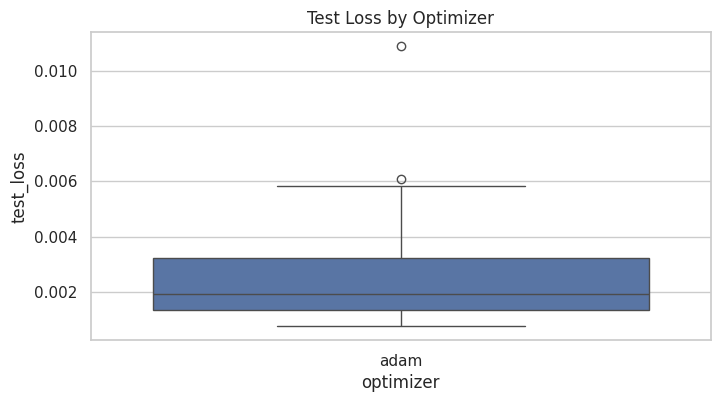

<ipython-input-21-299f10caa529>:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=results_df, x="dropout", y="test_loss", ci="sd")  #----!


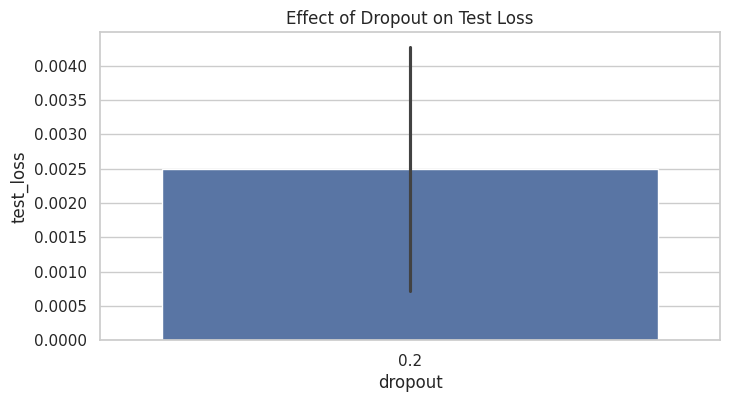

<ipython-input-21-299f10caa529>:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=results_df, x="hidden_size", y="test_loss", ci="sd")  #----!


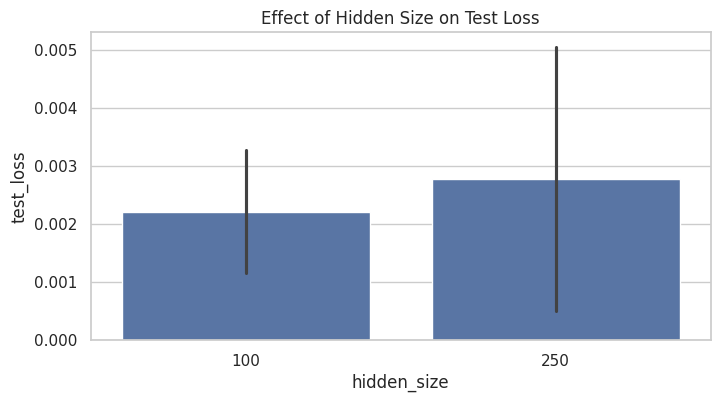

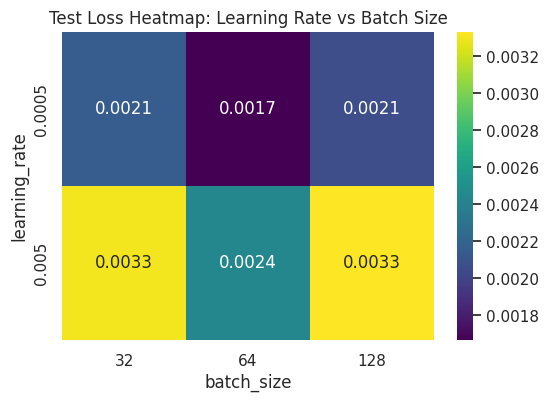

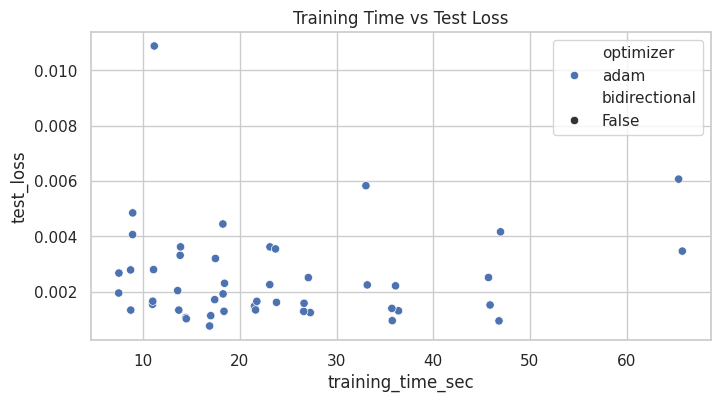

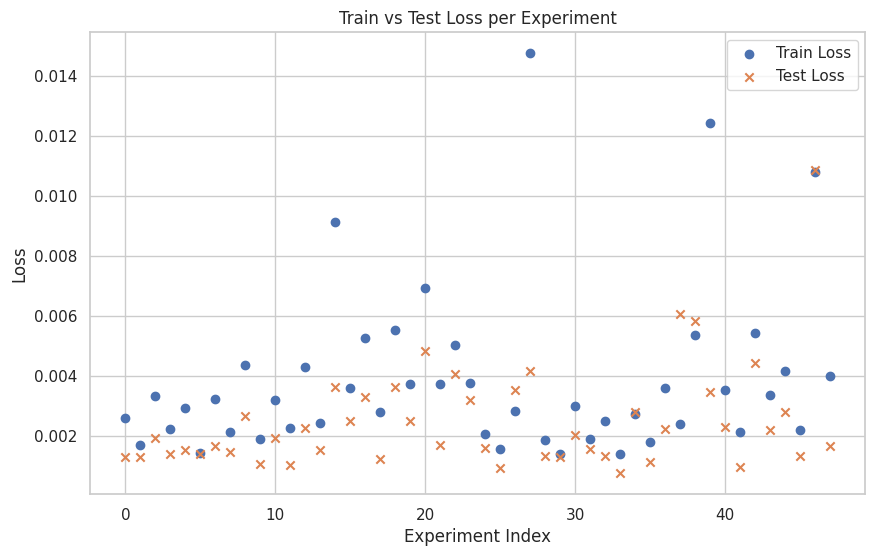

In [21]:
# ---- Visualizations ---- #----!
sns.set(style="whitegrid")  #----!

# Boxplot: Loss by Optimizer
plt.figure(figsize=(8, 4))
sns.boxplot(data=results_df, x="optimizer", y="test_loss")  #----!
plt.title("Test Loss by Optimizer")  #----!
plt.show()

# Barplot: Loss by Dropout
plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="dropout", y="test_loss", ci="sd")  #----!
plt.title("Effect of Dropout on Test Loss")  #----!
plt.show()

# Barplot: Loss by Hidden Size
plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="hidden_size", y="test_loss", ci="sd")  #----!
plt.title("Effect of Hidden Size on Test Loss")  #----!
plt.show()

# Heatmap: Learning Rate vs Batch Size
pivot = results_df.pivot_table(index="learning_rate", columns="batch_size", values="test_loss", aggfunc='mean')  #----!
plt.figure(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="viridis")  #----!
plt.title("Test Loss Heatmap: Learning Rate vs Batch Size")  #----!
plt.show()

# Scatterplot: Training Time vs Loss (colored by optimizer)
plt.figure(figsize=(8, 4))
sns.scatterplot(data=results_df, x="training_time_sec", y="test_loss", hue="optimizer", style="bidirectional")  #----!
plt.title("Training Time vs Test Loss")  #----!
plt.show()

# Additional: Train vs Test Loss Comparison
plt.figure(figsize=(10, 6))  #----!
plt.scatter(results_df.index, results_df["train_loss"], label="Train Loss", marker="o")  #----!
plt.scatter(results_df.index, results_df["test_loss"], label="Test Loss", marker="x")  #----!
plt.xlabel("Experiment Index")  #----!
plt.ylabel("Loss")  #----!
plt.title("Train vs Test Loss per Experiment")  #----!
plt.legend()  #----!
plt.grid(True)  #----!
plt.show()  #----!


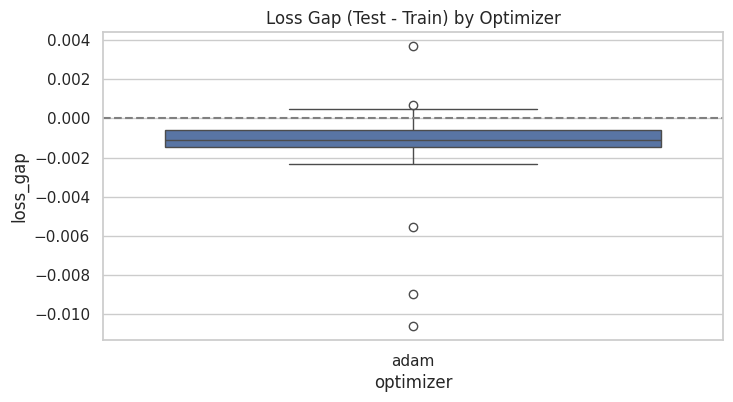

<ipython-input-22-476ed25b0bfb>:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=results_df, x="dropout", y="loss_gap", ci="sd")  #----!


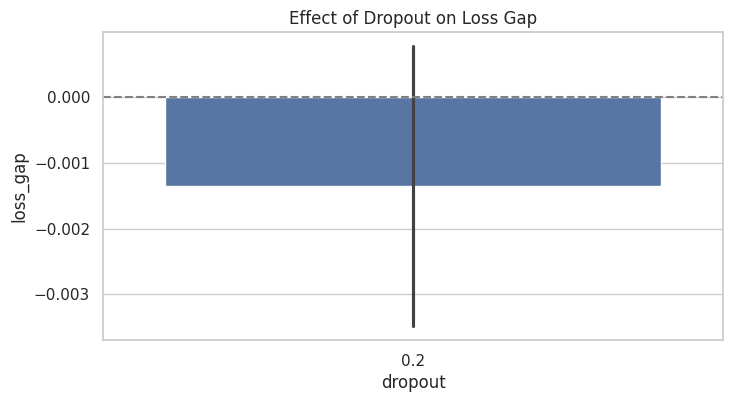

In [22]:

# Additional: Loss Gap (Overfitting Indicator) by Optimizer  #----!
results_df['loss_gap'] = results_df['test_loss'] - results_df['train_loss']  #----!
plt.figure(figsize=(8, 4))  #----!
sns.boxplot(data=results_df, x="optimizer", y="loss_gap")  #----!
plt.title("Loss Gap (Test - Train) by Optimizer")  #----!
plt.axhline(0, color='gray', linestyle='--')  #----!
plt.show()  #----!

# Additional: Loss Gap by Dropout  #----!
plt.figure(figsize=(8, 4))  #----!
sns.barplot(data=results_df, x="dropout", y="loss_gap", ci="sd")  #----!
plt.title("Effect of Dropout on Loss Gap")  #----!
plt.axhline(0, color='gray', linestyle='--')  #----!
plt.show()  #----!
